# [LAB-06] 2-2. Line Plot 옵션 설정

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import my_plot
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터셋 불러오기

In [2]:
origin = load_data('icecream_sales')
origin

📚 '달콤 스쿱' 아이스크림 가게의 매출 데이터 (인덱스 없음)


,Date,Flavor,Topping,Price,Quantity
0,2023-07-01,초콜릿,아몬드,3500,20.000
1,2023-07-01,바닐라,초코시럽,3000,25.000
2,2023-07-01,딸기,연유,3200,18.000
3,2023-07-02,민트초코,초코칩,3800,15.000
4,2023-07-02,초콜릿,아몬드,3500,22.000
5,2023-07-02,바닐라,None,3000,30.000
6,2023-07-03,딸기,연유,3200,25.000
7,2023-07-03,민트초코,초코칩,3800,NaN
8,2023-07-03,바닐라,초코시럽,3000,28.000
9,2023-07-04,초콜릿,아몬드,3500,18.000


## #02. 선 모양 설정 하기

### 1. 선 색상 / 선 스타일, 굵기 / 마커 모양, 크기, 테두리 색상, 면 색상, 테두리 굵기

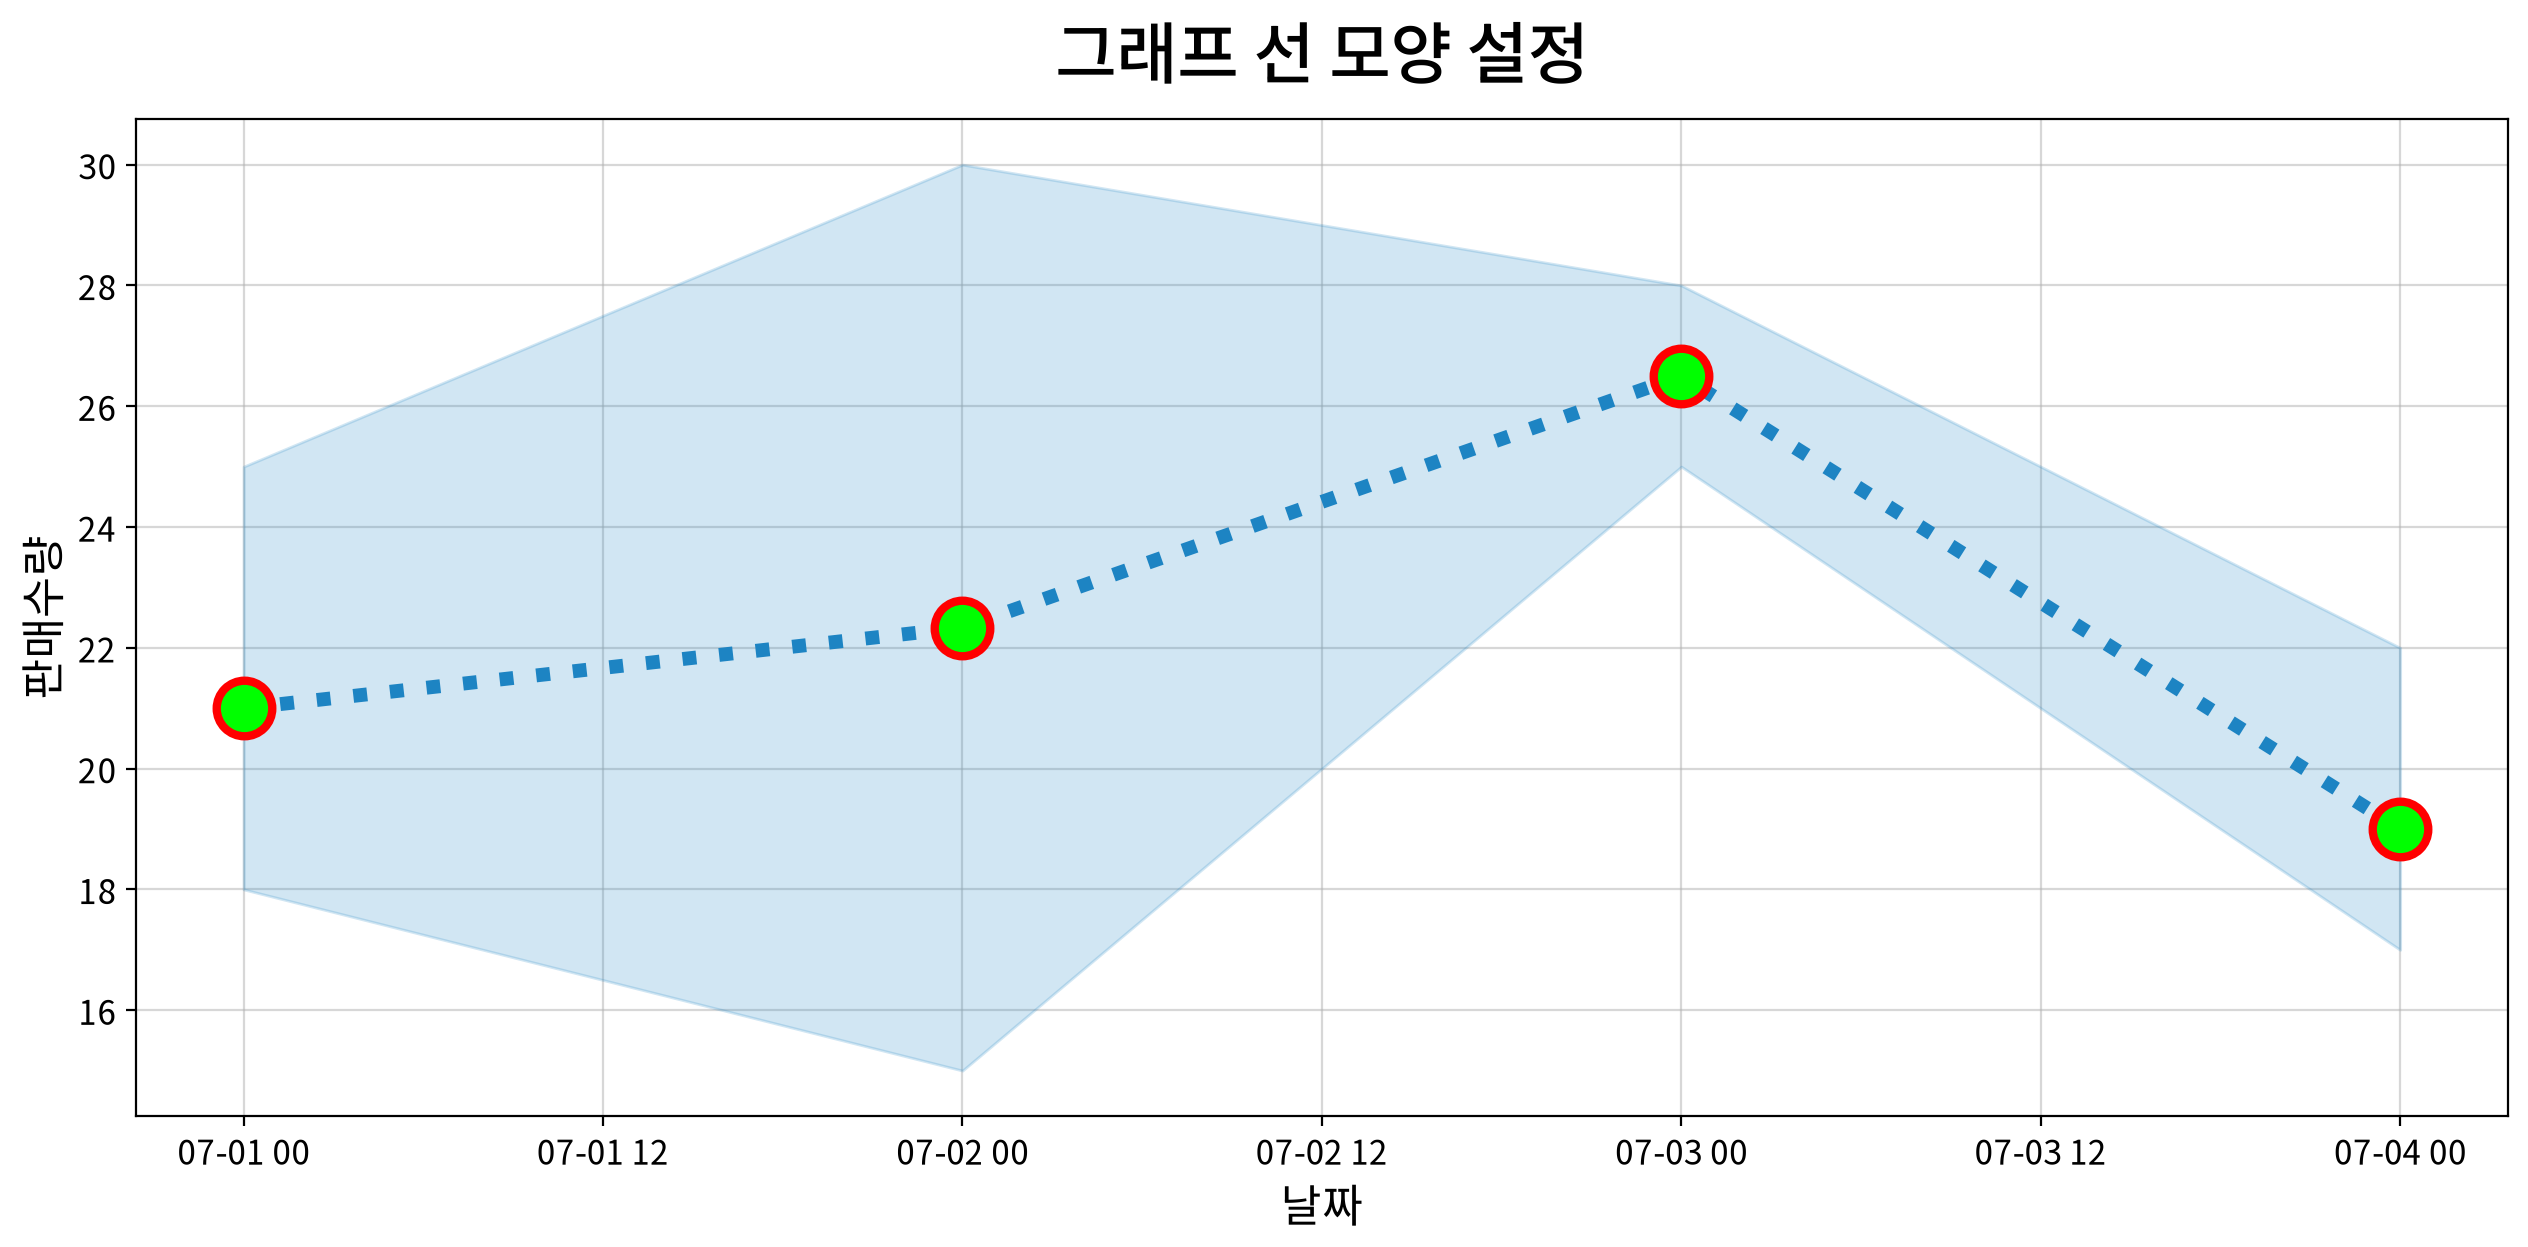

In [3]:
# 그래프 초기화
fig, ax = my_plot.init(title="그래프 선 모양 설정", xlabel="날짜", 
                       ylabel="판매수량")

# 그래프 그리기
sb.lineplot(data=origin, x='Date', y="Quantity",
            c="#1D84C3", linestyle=':', linewidth=5,
            marker="o", markersize=20, markeredgewidth=3,
            markerfacecolor="#00ff00", markeredgecolor="#ff0000")

# 출력
my_plot.show()

## #03. 축 설정

### 1. 축 범위/표시할 값 설정하기

- 축 범위 설정:
  - `ax`객체의 `set_xlim(), set_ylim()` 메서드를 사용한다.
- 축에 표시할 값 설정
  - `ax`객체의 `set_xticks(), set_yticks()` 메서드를 사용한다.

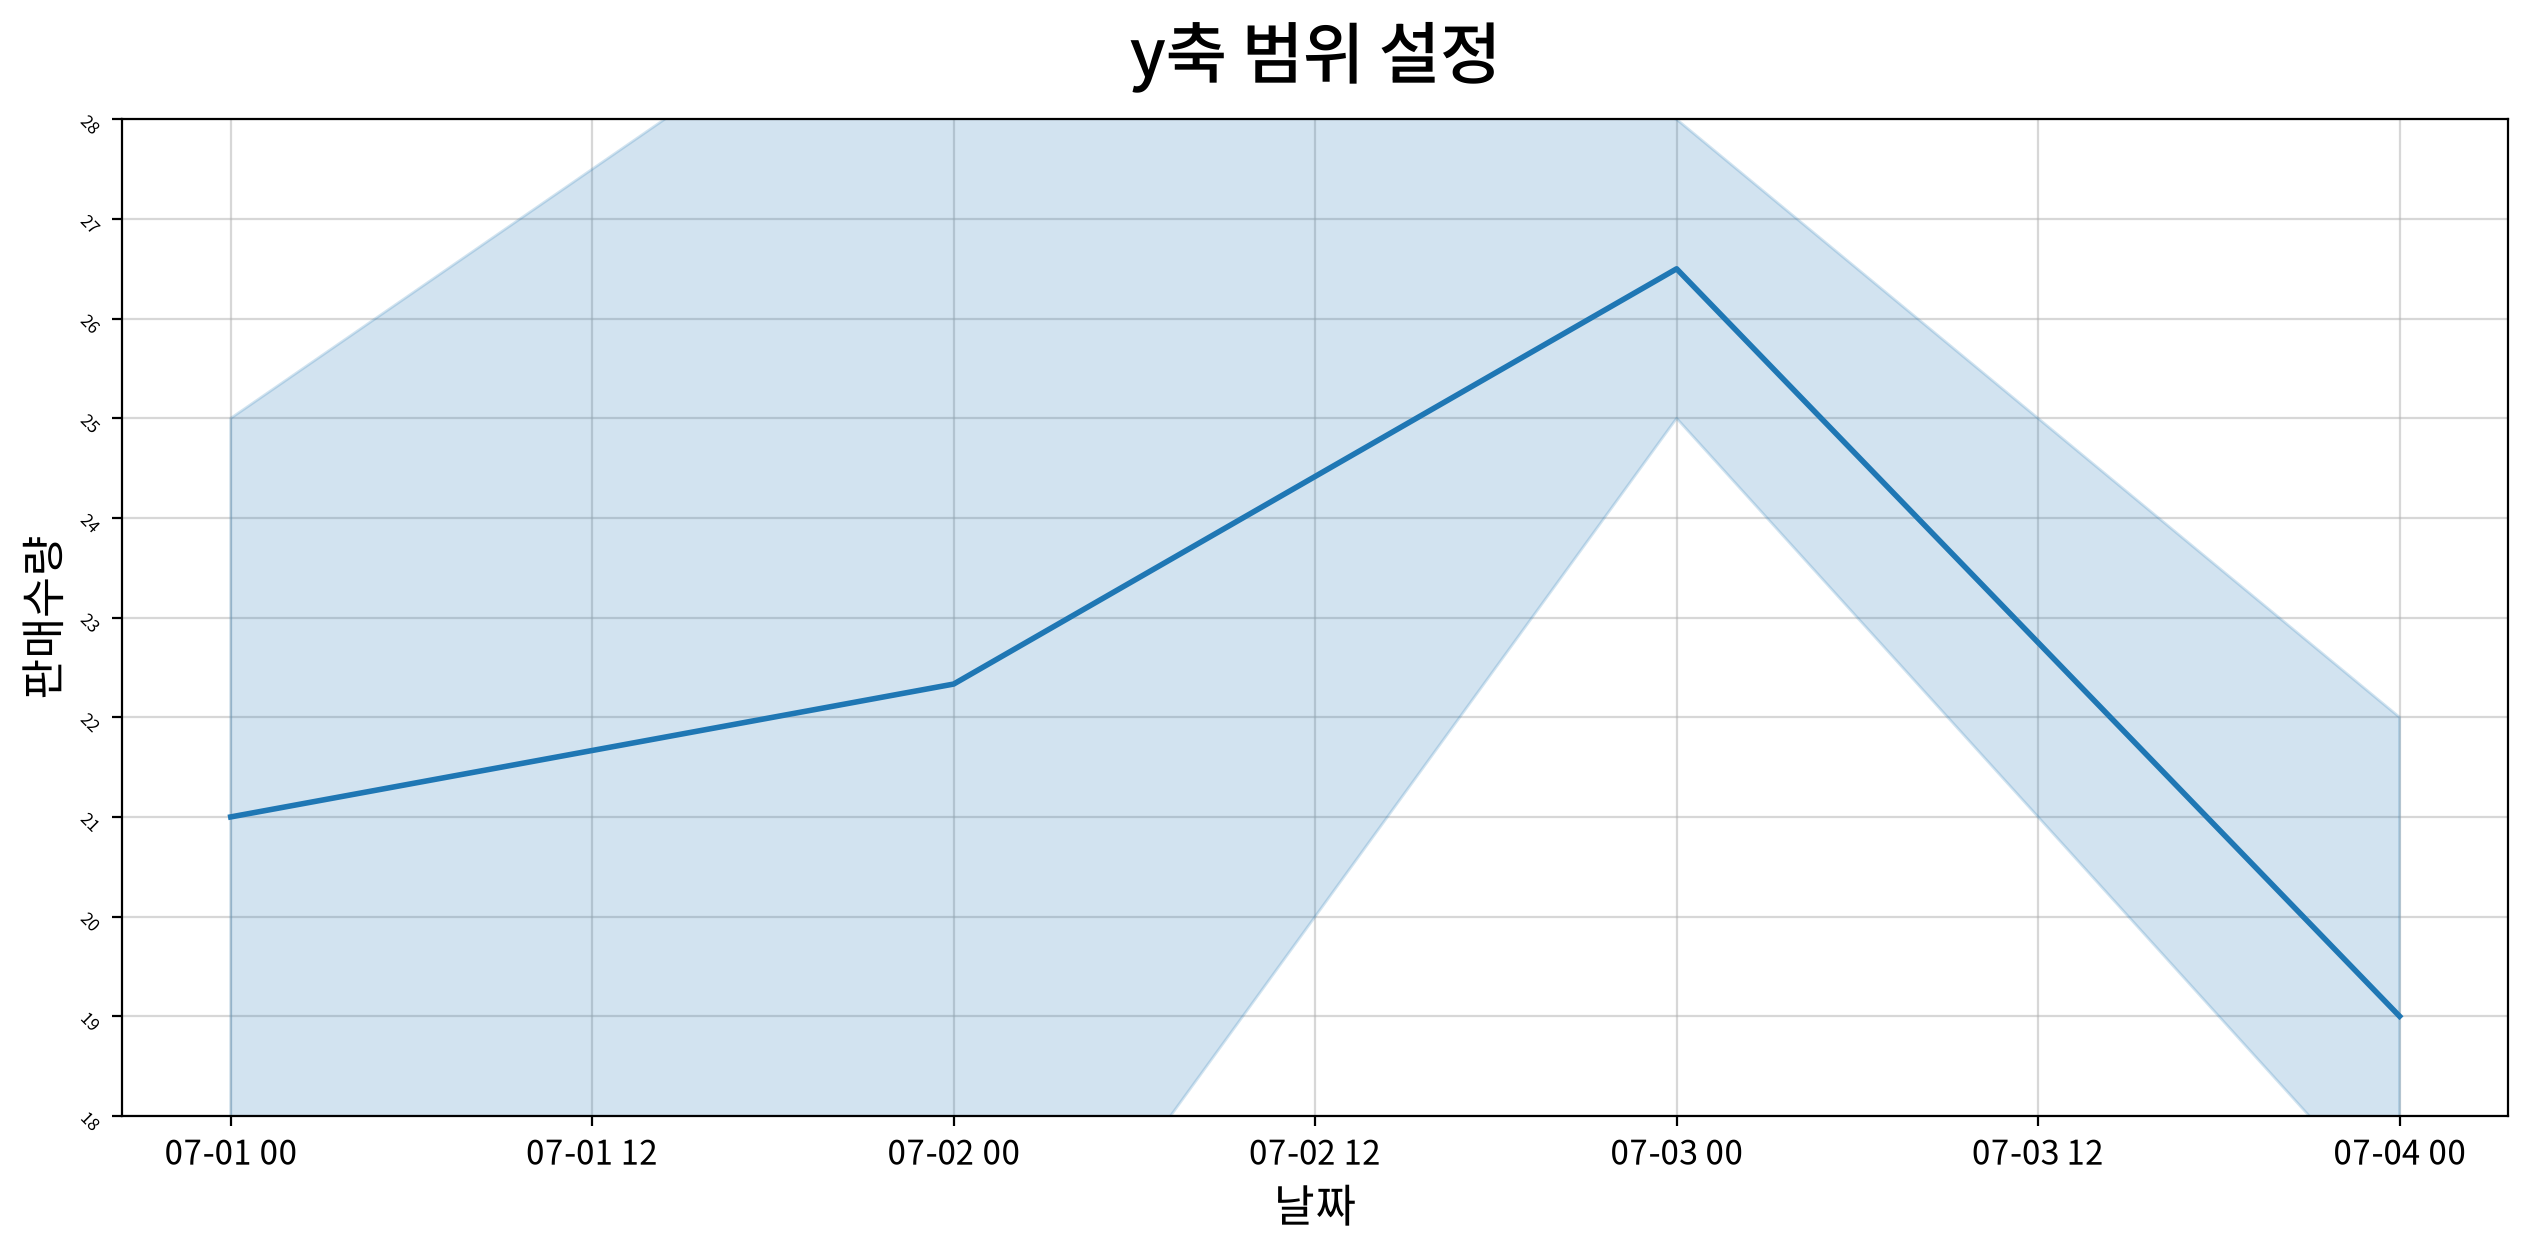

In [4]:
# 그래프 초기화
fig, ax = my_plot.init(title="y축 범위 설정", xlabel="날짜", ylabel="판매수량")

# 그래프 그리기
sb.lineplot(data=origin, x='Date', y="Quantity")

# y축 범위 (x축 범위 설정은 set_xlim)
ax.set_ylim(18, 28)

# y축에 표시할 값 설정
# --> [18~28]에 표시할 내용 내용을 [18~28] 범위의 실제 숫자로 지정
# --> 글자크기=6, 표시각도=-45도
ax.set_yticks(list(range(18, 29)), list(range(18, 29)), 
              fontsize=6, rotation=-45)

# 출력
my_plot.show()

## #04. 다중 선 그래프

### 1. 두 개 이상의 선 그리기

- 여러 라인 플롯을 동시에 그리는 경우에는 각 선이 무슨 자료를 표시하는지를 보여주기 위해 `ax.legend()` 명령으로  범례(legend)를 추가할 수 있다.
- 범례의 위치는 자동으로 정해지지만 수동으로 설정하고 싶으면 `loc` 파라미터에 위치를 의미하는 문자열 혹은 숫자를 설정한다. 

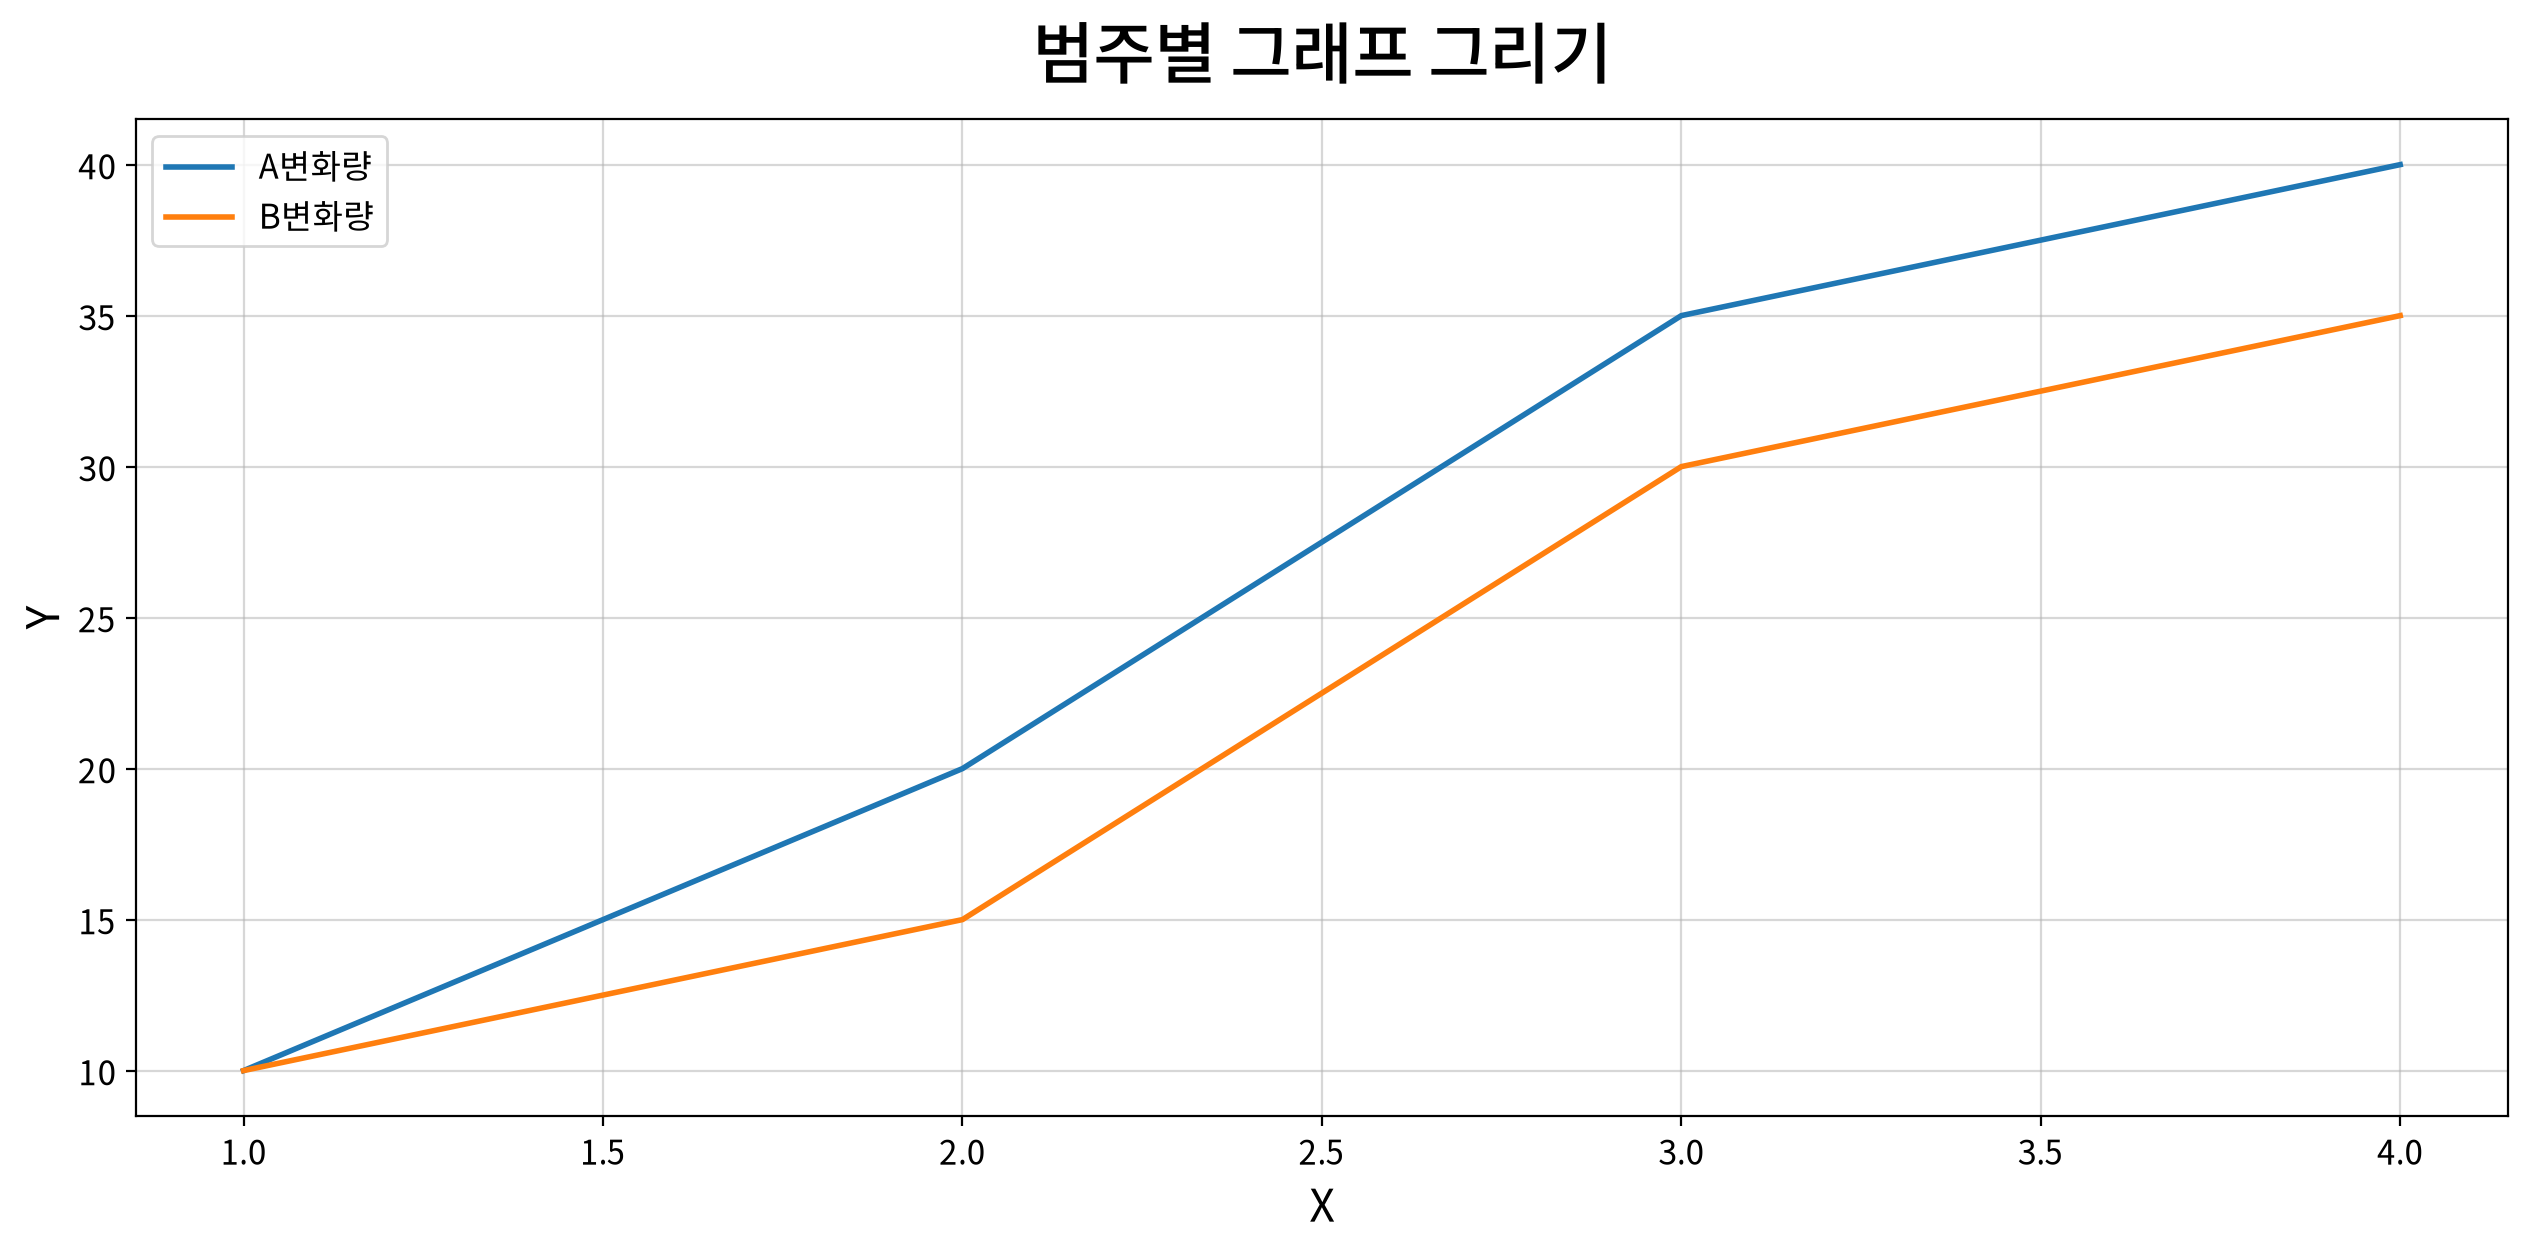

In [5]:
# 그래프 초기화
fig, ax = my_plot.init(title="범주별 그래프 그리기", xlabel="X", ylabel="Y")

# 그래프 그리기
sb.lineplot(x=[1, 2, 3, 4], y=[10, 20, 35, 40], label="A변화량")
sb.lineplot(x=[1, 2, 3, 4], y=[10, 15, 30, 35], label="B변화량")
ax.legend(loc='upper left')    # 범주의 위치 설정 (미설정시 자동으로 위치가 지정됨)

# 출력
my_plot.show()

## #05. 모듈화 기능 확인

### 모듈 변경사항 인식시키기

- 모듈 소스코드가 변경되면 jupyter에 변경 사항을 인식시키기 위해 jupyter를 재시작 해야 한다.
- jupyter가 재시작되면 지금까지의 모든 코드에 대한 재실행이 필요하다.

### 1. 선 그래프 모듈화

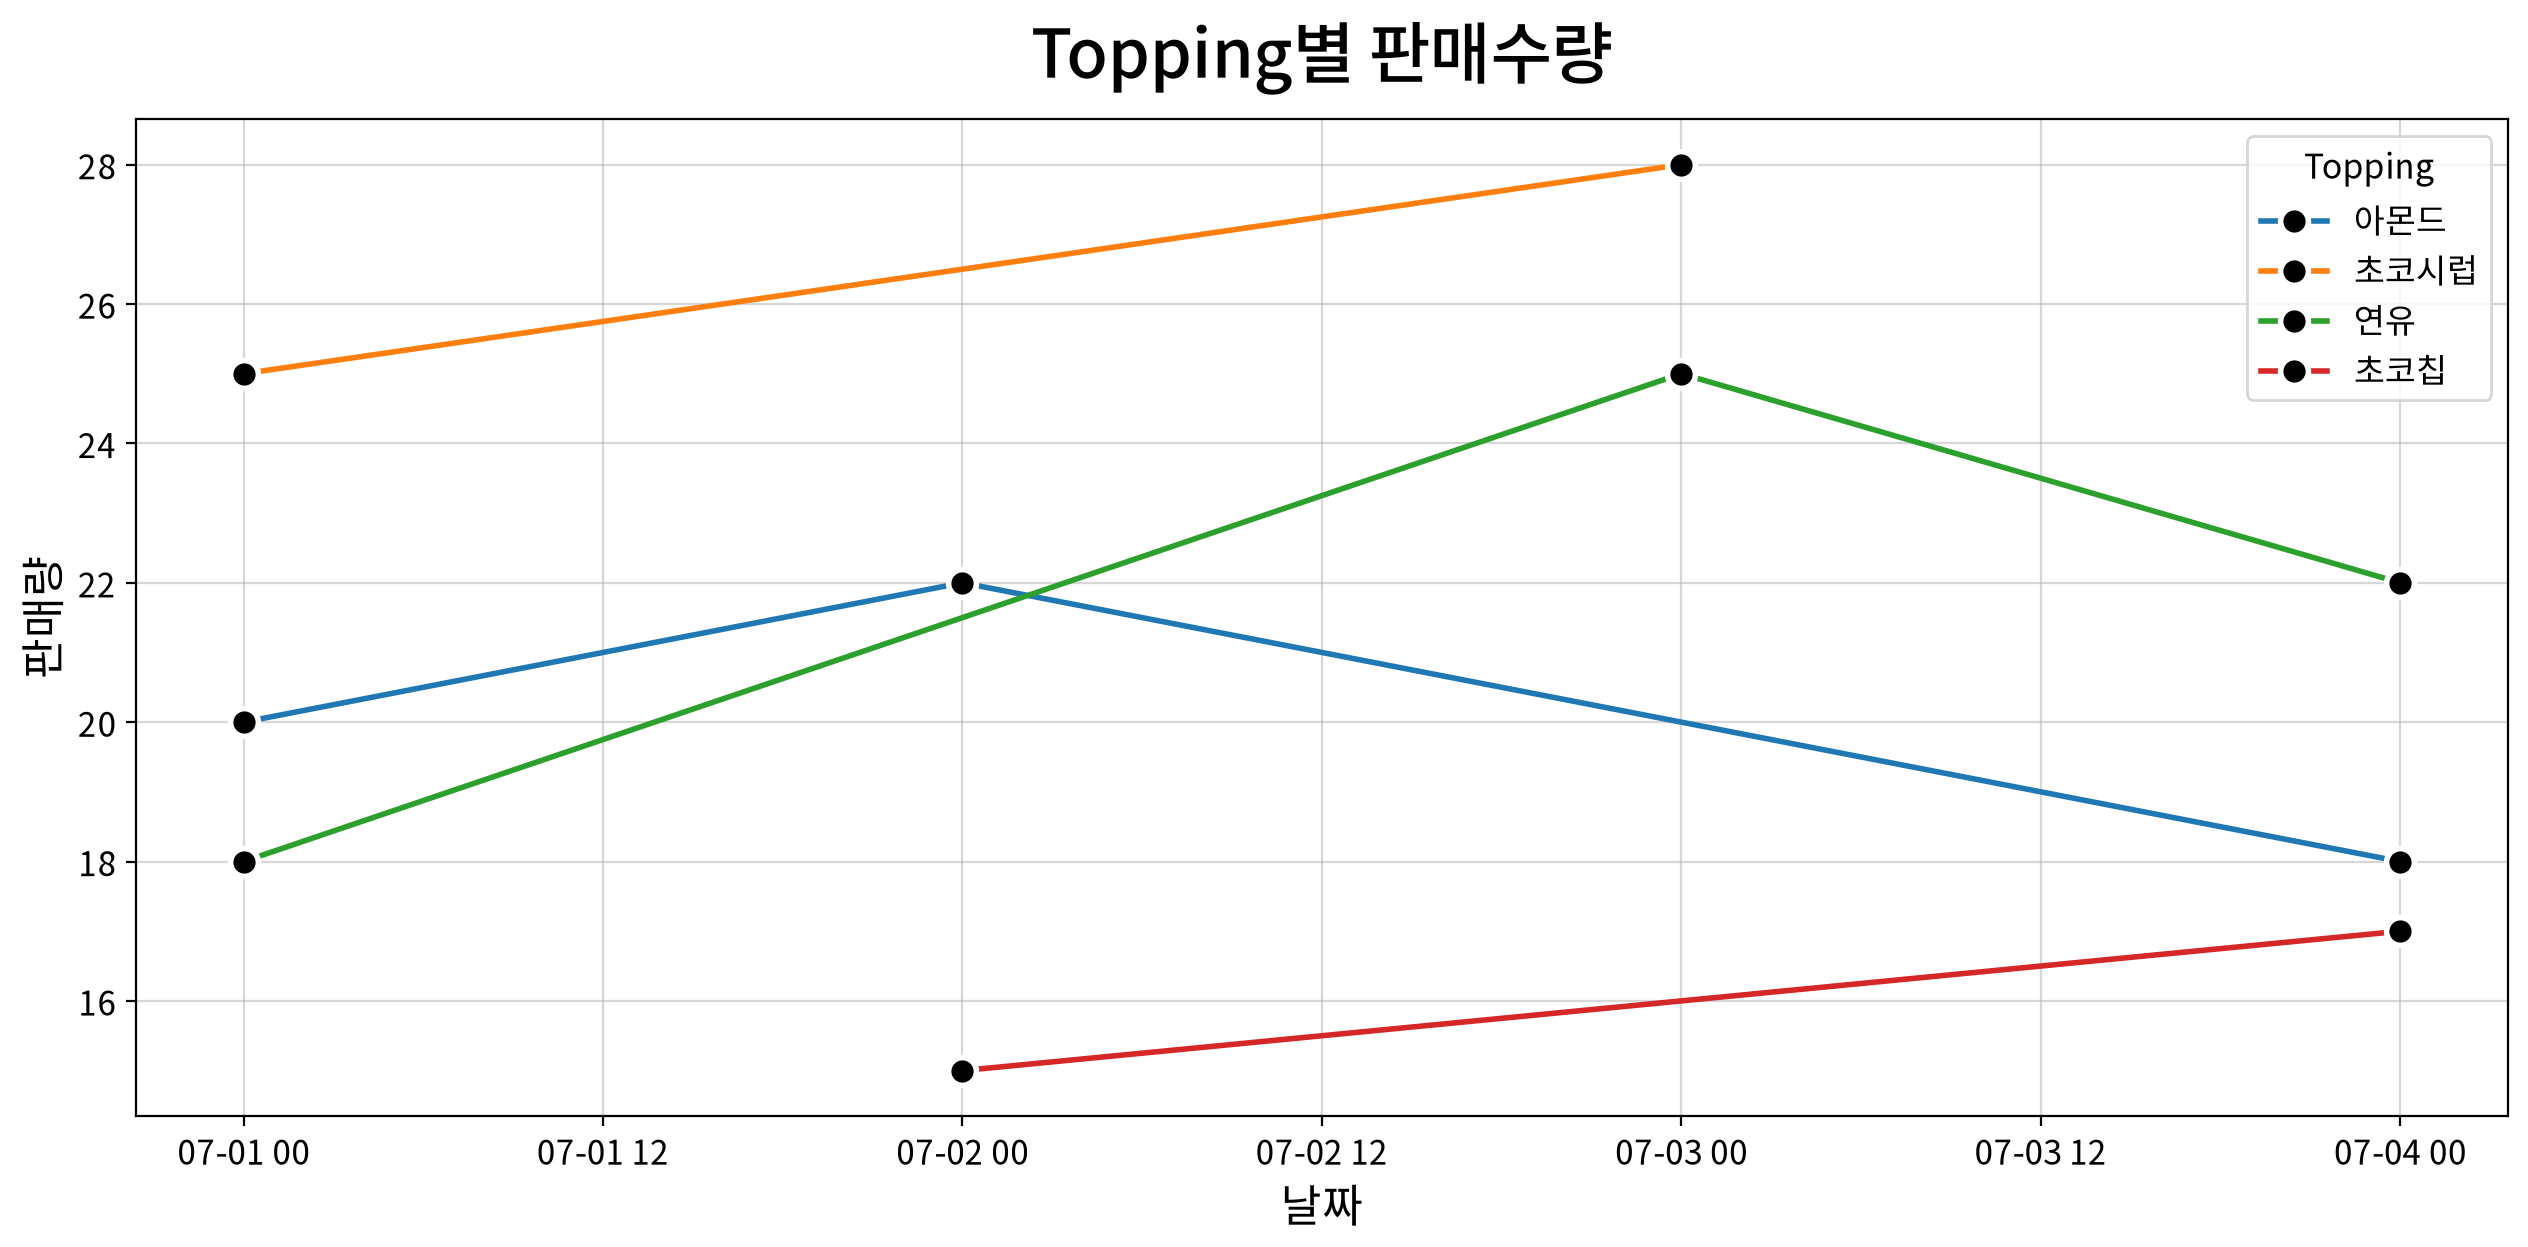

In [6]:
my_plot.lineplot(data=origin, x='Date', y="Quantity", hue="Topping",
                 title="Topping별 판매수량", xlabel="날짜", ylabel="판매량",
                 marker="o", markersize=10, markeredgewidth=2,
                 markerfacecolor="#000000", markeredgecolor="#ffffff")

#### 💡 인사이트

- 📊 전체 구간에서 초코시럽이 가장 높은 판매 수준을 보이며, 관측된 값은 25 → 28로 증가함.
- 📈 연유는 07-01부터 07-03까지 뚜렷한 상승(18 → 약 21~22 → 25) 후 07-04에 22로 하락함.
- 📉 아몬드는 07-02에 22로 정점 후 07-03, 07-04로 갈수록 감소(20 → 22 → 20 → 18)함.
- 🌱 초코칩은 표시된 구간(07-02~07-04)에서 15 → 16 → 17로 꾸준히 증가함.
- 🔄 07-03 시점에서 연유(25)가 아몬드(20)를 확실히 상회함.
- 🧩 토핑별 시계열 길이가 다름: 초코시럽은 2개 시점, 초코칩은 3개 시점만 표시되어 일부 날짜가 비어 있음.